In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestClassifier

(np.float64(-0.5), np.float64(2212.5), np.float64(1571.5), np.float64(-0.5))

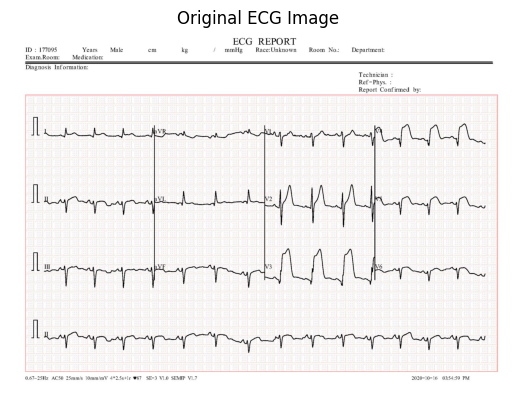

In [49]:
image_path = "/kaggle/input/datasets/genesisjupiter/mycardial/Ecg.jpg"  # change path
img = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original ECG Image")
plt.axis("off")

(np.float64(-0.5), np.float64(2212.5), np.float64(1571.5), np.float64(-0.5))

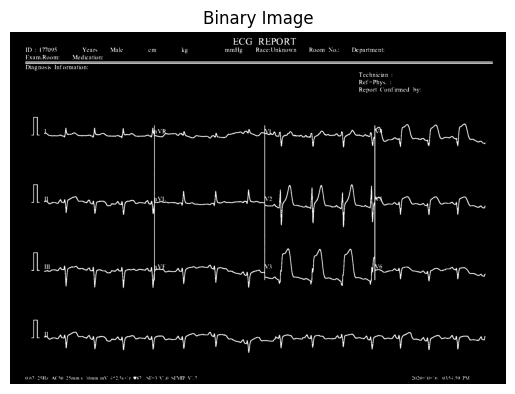

In [50]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Remove noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Binary threshold
_, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Binary Image")
plt.axis("off")

Text(0.5, 1.0, 'Single Lead')

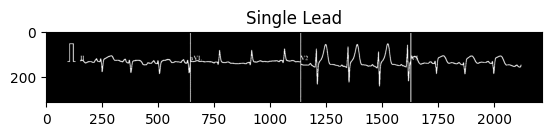

In [51]:
h, w = thresh.shape

# Crop middle region (adjust manually after visualization)
cropped = thresh[int(h*0.4):int(h*0.6), :]

plt.imshow(cropped, cmap='gray')
plt.title("Single Lead")

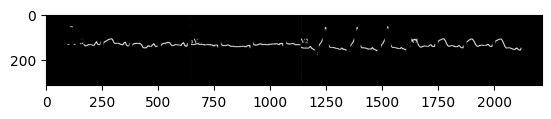

In [52]:
kernel = np.ones((15,1), np.uint8)
removed_vertical = cv2.morphologyEx(cropped, cv2.MORPH_OPEN, kernel)

clean = cv2.subtract(cropped, removed_vertical)

plt.imshow(clean, cmap='gray')

In [53]:
height, width = clean.shape
signal = []

for x in range(width):
    column = clean[:, x]
    y_coords = np.where(column == 255)[0]
    
    if len(y_coords) > 0:
        y = np.median(y_coords)   # 🔥 KEY CHANGE
    else:
        y = signal[-1] if signal else height//2
    
    signal.append(y)

signal = np.array(signal)

In [54]:
from scipy.signal import savgol_filter

signal = savgol_filter(signal, window_length=31, polyorder=3)

Text(0.5, 1.0, 'Fixed ECG Signal')

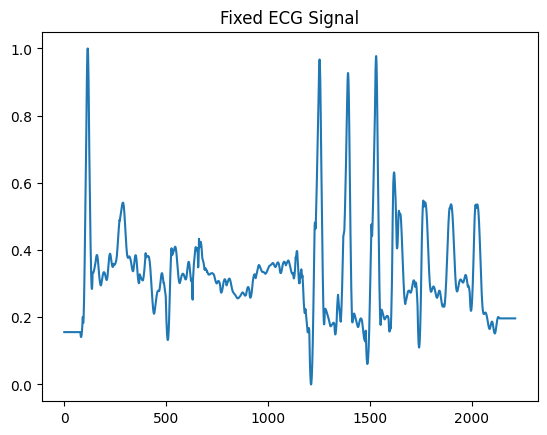

In [55]:
signal = height - signal
signal = (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

plt.plot(signal)
plt.title("Fixed ECG Signal")

Text(0.5, 1.0, 'Detected R Peaks')

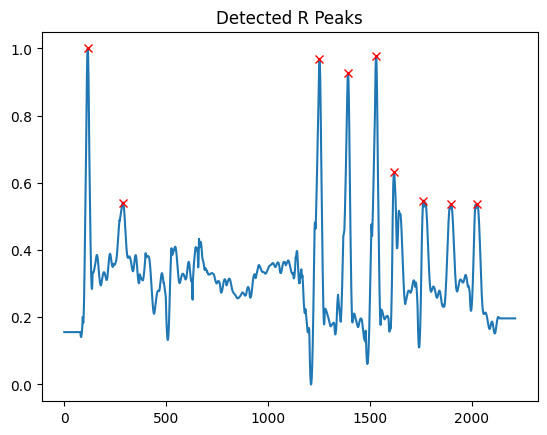

In [56]:
peaks, _ = find_peaks(signal, distance=50, height=0.5)

plt.figure()
plt.plot(signal)
plt.plot(peaks, signal[peaks], "rx")
plt.title("Detected R Peaks")

In [57]:
rr_intervals = np.diff(peaks)

features = [
    np.mean(rr_intervals) if len(rr_intervals)>0 else 0,
    np.std(rr_intervals) if len(rr_intervals)>0 else 0,
    len(peaks),
    np.max(signal),
    np.min(signal)
]

features = np.array(features).reshape(1, -1)

print("Extracted Features:", features)

Extracted Features: [[238.875      274.93746448   9.           1.           0.        ]]


In [58]:
# Dummy training data
X_train = np.random.rand(10, 5)
y_train = np.random.randint(0, 2, 10)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [59]:
prediction = model.predict(features)
confidence = model.predict_proba(features)

print("Prediction:", "Abnormal" if prediction[0] else "Normal")
print("Confidence:", confidence.max())

Prediction: Abnormal
Confidence: 0.61
